In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score,confusion_matrix,precision_score, recall_score,roc_auc_score,precision_recall_curve,balanced_accuracy_score
import optuna

In [2]:
df=pd.read_csv('CICIDS2018/02-14-2018.csv')

In [3]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [4]:
df.shape

(1048575, 80)

In [5]:
df['Label'].value_counts()

Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64

In [7]:
col=df.columns
col

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [8]:
df=df.drop(columns='Timestamp')

In [9]:
zero_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
zero_variance_cols

['Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'CWE Flag Count',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg']

In [10]:
df=df.drop(columns=zero_variance_cols)

In [11]:
zero_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
zero_variance_cols

[]

In [12]:
inf_nan_cols = df.columns[
    (df.isin([np.inf, -np.inf]).any(axis=0)) | (df.isna().any(axis=0))
]

print(inf_nan_cols)

Index(['Flow Byts/s', 'Flow Pkts/s'], dtype='object')


In [13]:
df['Flow Byts/s'] = df['Flow Byts/s'].replace([np.inf, -np.inf], np.nan)
df['Flow Pkts/s'] = df['Flow Pkts/s'].replace([np.inf, -np.inf], np.nan)

In [14]:
df['Flow Byts/s'] = df['Flow Byts/s'].fillna(0)
df['Flow Pkts/s'] = df['Flow Pkts/s'].fillna(0)

In [15]:
inf_nan_cols = df.columns[
    (df.isin([np.inf, -np.inf]).any(axis=0)) | (df.isna().any(axis=0))
]

print(inf_nan_cols)

Index([], dtype='object')


In [17]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

In [18]:
df['Label'].value_counts()

Label
0    667626
1    380949
Name: count, dtype: int64

In [19]:
X = df.drop('Label', axis=1)
y = df['Label']

In [20]:
print(X.shape,y.shape)

(1048575, 68) (1048575,)


In [21]:
y.value_counts()

Label
0    667626
1    380949
Name: count, dtype: int64

In [22]:
X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [23]:
print(X_train.shape,X_val.shape,y_train.shape,y_val.shape)

(838860, 68) (209715, 68) (838860,) (209715,)


In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [25]:
def objective(trial):

    C = trial.suggest_float("C", 1e-4, 10, log=True)
    solver = trial.suggest_categorical("solver", ["saga", "lbfgs"])
    max_iter = trial.suggest_int("max_iter", 200, 2000)

    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    return f1_score(y_val, y_pred, average="weighted")

In [26]:
print("Starting Optuna optimization ...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-03-05 16:15:05,073] A new study created in memory with name: no-name-6ecfad39-27d9-468b-b99b-b16802c01b63


Starting Optuna optimization ...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-05 16:15:10,641] Trial 0 finished with value: 0.999680547121759 and parameters: {'C': 1.4294233100754572, 'solver': 'lbfgs', 'max_iter': 1490}. Best is trial 0 with value: 0.999680547121759.


C:\Users\Mominul Hoque\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[I 2026-03-05 16:48:19,130] Trial 3 finished with value: 0.9990132272975063 and parameters: {'C': 0.314822341977997, 'solver': 'saga', 'max_iter': 342}. Best is trial 0 with value: 0.999680547121759.
[I 2026-03-05 17:03:22,047] Trial 4 finished with value: 0.9990322899580383 and parameters: {'C': 0.0004164972464400022, 'solver': 'saga', 'max_iter': 1447}. Best is trial 0 with value: 0.999680547121759.
[I 2026-03-05 17:03:26,245] Trial 5 finished with value: 0.9996662446687302 and parameters: {'C': 0.079920243860158, 'solver': 'lbfgs', 'max_iter': 1907}. Best is trial 0 with value: 0.999680547121759.


C:\Users\Mominul Hoque\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-03-05 17:25:01,777] Trial 6 finished with value: 0.9994231213762311 and parameters: {'C': 7.077311801783883, 'solver': 'saga', 'max_iter': 962}. Best is trial 0 with value: 0.999680547121759.


C:\Users\Mominul Hoque\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-03-05 17:39:02,436] Trial 7 finished with value: 0.9993849875402584 and parameters: {'C': 0.12822962103987412, 'solver': 'saga', 'max_iter': 622}. Best is trial 0 with value: 0.999680547121759.
[I 2026-03-05 17:39:07,547] Trial 8 finished with value: 0.999680547121759 and parameters: {'C': 1.9283201922543822, 'solver': 'lbfgs', 'max_iter': 1040}. Best is trial 0 with value: 0.999680547121759.
[I 2026-03-05 17:39:13,788] Trial 9 finished with value: 0.9996662446687302 and parameters: {'C': 6.4577429993039255, 'solver': 'lbfgs', 'max_iter': 228}. Best is trial 0 with value: 0.999680547121759.
[I 2026-03-05 17:39:20,580] Trial 10 finished with value: 0.999537528008522 and parameters: {'C': 0.007609729158890473, 'solver': 'lbfgs', 'max_iter': 1423}. Best is trial 0 with value: 0.999680547121759.
[I 2026-03-05 17:39:26,763] Trial 11 finished with value: 0.9996662446687302 and parameters: {'C': 0.6394067106011898, 'solver': 'lbfgs', 'max_iter': 1820}. Best is trial 0 with value: 0.99

In [27]:
print(f"Best f1_score: {study.best_trial.value:.4f}")
print(f"Best Parameters: {study.best_trial.params}")
best_params = study.best_trial.params

Best f1_score: 0.9997
Best Parameters: {'C': 1.4294233100754572, 'solver': 'lbfgs', 'max_iter': 1490}


In [28]:
lr= LogisticRegression(**study.best_params)
lr.fit(X_train, y_train)

LogisticRegression(C=1.4294233100754572, max_iter=1490)

In [29]:
y_val_pred = lr.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred, average="weighted"))
print(classification_report(y_val, y_val_pred))

Accuracy: 0.9996805187993228
F1 Score: 0.999680547121759
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    133525
           1       1.00      1.00      1.00     76190

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [30]:
y_val.value_counts()

Label
0    133525
1     76190
Name: count, dtype: int64

In [31]:
confusion_matrix(y_val, y_val_pred)

array([[133460,     65],
       [     2,  76188]])

In [32]:
test_df=pd.read_csv('CICIDS2018/02-16-2018.csv')

C:\Users\Mominul Hoque\AppData\Local\Temp\ipykernel_1520\2001528650.py:1: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df=pd.read_csv('CICIDS2018/02-16-2018.csv')


In [33]:
test_df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,16/02/2018 08:27:23,112640768,3,0,0,0,0,0,...,0,0,0.0,0,0,56300000.0,138.592929,56300000,56300000,Benign
1,0,0,16/02/2018 08:30:12,112641773,3,0,0,0,0,0,...,0,0,0.0,0,0,56300000.0,263.750829,56300000,56300000,Benign
2,35605,6,16/02/2018 08:26:55,20784143,23,44,2416,1344,240,64,...,20,2624734,0.0,2624734,2624734,9058214.0,0.0,9058214,9058214,Benign
3,0,0,16/02/2018 08:33:01,112640836,3,0,0,0,0,0,...,0,0,0.0,0,0,56300000.0,82.024387,56300000,56300000,Benign
4,23,6,16/02/2018 08:27:59,20,1,1,0,0,0,0,...,20,0,0.0,0,0,0.0,0.0,0,0,Benign


In [34]:
test_df['Label'].value_counts()

Label
DoS attacks-Hulk            461912
Benign                      446772
DoS attacks-SlowHTTPTest    139890
Label                            1
Name: count, dtype: int64

In [35]:
test_df = test_df[test_df['Label'] != 'Label']

In [36]:
test_df['Label'].value_counts()

Label
DoS attacks-Hulk            461912
Benign                      446772
DoS attacks-SlowHTTPTest    139890
Name: count, dtype: int64

In [37]:
test_col=df.columns
test_col

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max',
       'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt',
       'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
       'URG Flag Cnt', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts',
       'Subflow Fwd Byts', '

In [38]:
test_df=test_df.drop(columns='Timestamp')

In [39]:
zero_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
zero_variance_cols

[]

In [40]:
inf_nan_cols = df.columns[
    (df.isin([np.inf, -np.inf]).any(axis=0)) | (df.isna().any(axis=0))
]

print(inf_nan_cols)

Index([], dtype='object')


In [41]:
cols = list(df.columns)
test_cols = list(test_df.columns)

if cols == test_cols:
    print("Columns match exactly")
else:
    print("Columns do NOT match")

    print("\nColumns missing in test dataset:")
    print(set(cols) - set(test_cols))

    print("\nExtra columns in test dataset:")
    print(set(test_cols) - set(cols))

Columns do NOT match

Columns missing in test dataset:
set()

Extra columns in test dataset:
{'Fwd Byts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Fwd Pkts/b Avg', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Bwd Blk Rate Avg'}


In [42]:
# Remove extra columns
test_df = test_df[[col for col in cols if col in test_df.columns]]

# Add missing columns
for col in cols:
    if col not in test_df.columns:
        test_df[col] = 0

# Reorder columns
test_df = test_df[cols]

print("Test dataset columns fixed")

Test dataset columns fixed


In [43]:
cols = list(df.columns)
test_cols = list(test_df.columns)

if cols == test_cols:
    print("Columns match exactly")
else:
    print("Columns do NOT match")

    print("\nColumns missing in test dataset:")
    print(set(cols) - set(test_cols))

    print("\nExtra columns in test dataset:")
    print(set(test_cols) - set(cols))

Columns match exactly


In [44]:
test_df['Label'] = test_df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

In [45]:
test_df['Label'].value_counts()

Label
1    601802
0    446772
Name: count, dtype: int64

In [46]:
X_test = test_df.drop("Label", axis=1)
y_test = test_df["Label"]

In [47]:
X_test = scaler.transform(X_test)

In [48]:
y_test_pred = lr.predict(X_test)


--- Evaluation:logistics regression in test data ---
Accuracy: 0.5681
F1 Score: 0.3969

Classification Report:

              precision    recall  f1-score   support

           0       0.50      1.00      0.66    446772
           1       1.00      0.25      0.40    601802

    accuracy                           0.57   1048574
   macro avg       0.75      0.62      0.53   1048574
weighted avg       0.79      0.57      0.51   1048574



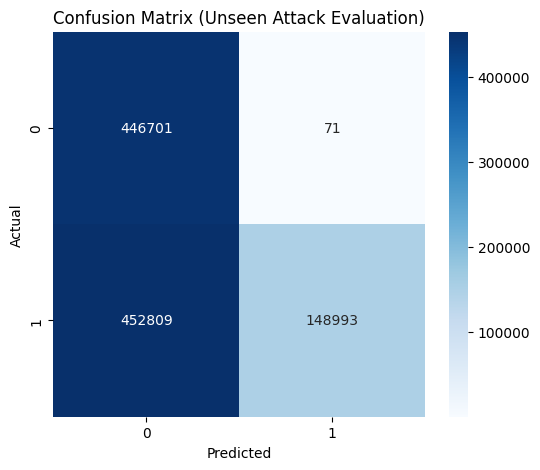


ROC-AUC: 0.9998


In [75]:
# Predictions
print("\n--- Evaluation:logistics regression in test data ---")
y_prob = lr.predict_proba(X_test)[:, 1] # Get probabilities for the positive class (Attack)

# Accuracy & F1
acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Unseen Attack Evaluation)")
plt.show()

# ROC-AUC (Binary)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC: {roc_auc:.4f}")

In [53]:
lr_oof_probs = cross_val_predict(lr, X_train, y_train, cv=3, method='predict_proba', n_jobs=-1)[:, 1]

In [54]:
lr_oof_probs

array([3.75771105e-10, 9.99950831e-01, 1.00000000e+00, ...,
       1.00000000e+00, 1.34166271e-10, 9.99999999e-01])

In [55]:
X_train_rf = np.column_stack((X_train, lr_oof_probs))
print(f"Old X_train shape: {X_train.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_train_rf.shape}")

Old X_train shape: (838860, 68)
New X_train_rf shape (with LR prob feature): (838860, 69)


In [56]:
lr_test_probs = lr.predict_proba(X_test)[:, 1]

In [57]:
lr_test_probs

array([7.67952822e-18, 7.67952803e-18, 1.27564644e-21, ...,
       9.99999898e-01, 9.99975154e-01, 1.00000000e+00])

In [58]:
X_test_rf = np.column_stack((X_test, lr_test_probs))

In [59]:
print(f"Old X_train shape: {X_test.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_test_rf.shape}")

Old X_train shape: (1048574, 68)
New X_train_rf shape (with LR prob feature): (1048574, 69)


In [60]:
lr_val_probs = lr.predict_proba(X_val)[:, 1]
X_val_rf = np.column_stack((X_val, lr_val_probs))

In [61]:
print(f"Old X_train shape: {X_val.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_val_rf.shape}")

Old X_train shape: (209715, 68)
New X_train_rf shape (with LR prob feature): (209715, 69)


In [62]:
# 2. Define the Optuna Objective Function for Random Forest
def objective_rf(trial):
    # The hyperparameters we want to test
    n_estimators = trial.suggest_int("n_estimators", 50, 200, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 25)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    # Initialize the model with the trial parameters
    rf_tune = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )

    # Train on the training data (which includes LR probs)
    rf_tune.fit(X_train_rf, y_train)

    # Predict on the validation data (which also includes LR probs)
    y_val_pred_rf = rf_tune.predict(X_val_rf)

    # We optimize for the weighted F1 score, just like you did for LR
    return f1_score(y_val, y_val_pred_rf, average="weighted")

In [64]:
print("\n--- Starting Optuna Optimization for Random Forest ---")
# 3. Run the study (Limited to 10 trials to save computation time)
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

[I 2026-03-10 19:52:42,087] A new study created in memory with name: no-name-48f96abc-a701-4fab-8ea5-1d1d71cefc8a



--- Starting Optuna Optimization for Random Forest ---


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-10 19:53:35,659] Trial 0 finished with value: 0.999995231617152 and parameters: {'n_estimators': 150, 'max_depth': 16, 'min_samples_split': 4}. Best is trial 0 with value: 0.999995231617152.
[I 2026-03-10 19:54:12,466] Trial 1 finished with value: 0.999990463247741 and parameters: {'n_estimators': 100, 'max_depth': 11, 'min_samples_split': 5}. Best is trial 0 with value: 0.999995231617152.
[I 2026-03-10 19:54:30,850] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 50, 'max_depth': 22, 'min_samples_split': 3}. Best is trial 2 with value: 1.0.
[I 2026-03-10 19:55:37,685] Trial 3 finished with value: 0.9999856948514556 and parameters: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 9}. Best is trial 2 with value: 1.0.
[I 2026-03-10 19:56:29,758] Trial 4 finished with value: 0.999995231617152 and parameters: {'n_estimators': 150, 'max_depth': 25, 'min_samples_split': 3}. Best is trial 2 with value: 1.0.
[I 2026-03-10 19:56:46,183] Trial 5 finished wi

In [65]:
# 4. Output the best results
print(f"\nBest RF F1 Score: {study_rf.best_trial.value:.4f}")
print(f"Best RF Parameters: {study_rf.best_trial.params}")

# 5. Save the best parameters to use in our actual pipeline
best_rf_params = study_rf.best_trial.params


Best RF F1 Score: 1.0000
Best RF Parameters: {'n_estimators': 50, 'max_depth': 22, 'min_samples_split': 3}


In [70]:
rf_final=RandomForestClassifier(**best_rf_params, 
    random_state=42,
    n_jobs=-1)
rf_final.fit(X_train_rf, y_train)

RandomForestClassifier(max_depth=22, min_samples_split=3, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [71]:
y_val_rf_pred = rf_final.predict(X_val_rf)

print("Accuracy:", accuracy_score(y_val, y_val_rf_pred))
print("F1 Score:", f1_score(y_val, y_val_rf_pred))
print(classification_report(y_val, y_val_rf_pred))

Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    133525
           1       1.00      1.00      1.00     76190

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [72]:
y_test_pred_rf = rf_final.predict(X_test_rf)
y_prob_rf = rf_final.predict_proba(X_test_rf)[:, 1]

In [76]:
print("\n--- Evaluation:  Random Forest in test data ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_rf):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_rf))


--- Evaluation:  Random Forest in test data ---
Accuracy: 0.5595
F1 Score: 0.3772
ROC-AUC:  0.9947

Classification Report:

              precision    recall  f1-score   support

           0       0.49      1.00      0.66    446772
           1       1.00      0.23      0.38    601802

    accuracy                           0.56   1048574
   macro avg       0.75      0.62      0.52   1048574
weighted avg       0.78      0.56      0.50   1048574



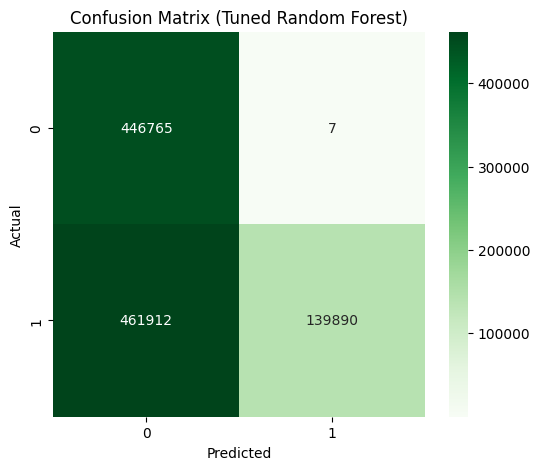

In [74]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.show()

In [78]:
rf_oof_probs = cross_val_predict(rf_final, X_train_rf, y_train, cv=3, method='predict_proba', n_jobs=-1)[:, 1]
X_train_xgb = np.column_stack((X_train_rf, rf_oof_probs))

In [79]:
print(f"Old X_train shape: {X_train.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_train_xgb.shape}")

Old X_train shape: (838860, 68)
New X_train_rf shape (with LR prob feature): (838860, 70)


In [80]:
rf_test_probs = rf_final.predict_proba(X_test_rf)[:, 1]
X_test_xgb = np.column_stack((X_test_rf, rf_test_probs))

In [81]:
print(f"Old X_train shape: {X_test.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_test_xgb.shape}")

Old X_train shape: (1048574, 68)
New X_train_rf shape (with LR prob feature): (1048574, 70)


In [83]:
rf_val_probs = rf_final.predict_proba(X_val_rf)[:, 1]
X_val_xgb = np.column_stack((X_val_rf, rf_val_probs))

In [84]:
print(f"Old X_train shape: {X_val.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_val_xgb.shape}")

Old X_train shape: (209715, 68)
New X_train_rf shape (with LR prob feature): (209715, 70)


In [85]:
def objective_xgb(trial):
    # Hyperparameters specifically tailored for a meta-learner
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 150, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 9), # Keep trees relatively shallow
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0), # Helps prevent overfitting
        "random_state": 42,
        "n_jobs": -1
    }

    # Initialize XGBoost with trial parameters
    xgb_tune = XGBClassifier(**params)

    # Train on the FULL stacked training dataset
    xgb_tune.fit(X_train_xgb, y_train)

    # Predict on the full validation data
    y_val_pred_xgb = xgb_tune.predict(X_val_xgb)

    # Optimize for the weighted F1 score
    return f1_score(y_val, y_val_pred_xgb, average="weighted")

In [86]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

[I 2026-03-10 20:55:15,166] A new study created in memory with name: no-name-2cd6229c-5975-4c6d-bab8-f595fe03a4e8


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-10 20:55:25,045] Trial 0 finished with value: 0.999995231617152 and parameters: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.17943715451618616, 'subsample': 0.9328549868725458}. Best is trial 0 with value: 0.999995231617152.
[I 2026-03-10 20:55:31,936] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.06306234636618499, 'subsample': 0.7795229148965075}. Best is trial 1 with value: 1.0.
[I 2026-03-10 20:55:36,237] Trial 2 finished with value: 0.999990463220866 and parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.01035341580737043, 'subsample': 0.9066940019989126}. Best is trial 1 with value: 1.0.
[I 2026-03-10 20:55:40,628] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.10300627210100698, 'subsample': 0.7988396948847724}. Best is trial 1 with value: 1.0.
[I 2026-03-10 20:55:44,947] Trial 4 finished with value: 0.999990463220866 and p

In [87]:
print(f"\nBest XGB F1 Score: {study_xgb.best_trial.value:.4f}")
print(f"Best XGB Parameters: {study_xgb.best_trial.params}")

best_xgb_params = study_xgb.best_trial.params


Best XGB F1 Score: 1.0000
Best XGB Parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.06306234636618499, 'subsample': 0.7795229148965075}


In [88]:
xgb_final = XGBClassifier(
    **best_xgb_params,
    random_state=42,
    n_jobs=-1
)

In [89]:
xgb_final.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.06306234636618499, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [91]:
y_val_xgb_pred = xgb_final.predict(X_val_xgb)

print("Accuracy:", accuracy_score(y_val, y_val_xgb_pred))
print("F1 Score:", f1_score(y_val, y_val_xgb_pred))
print(classification_report(y_val, y_val_xgb_pred))

Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    133525
           1       1.00      1.00      1.00     76190

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [94]:
y_test_pred_xgb = xgb_final.predict(X_test_xgb)

In [95]:
y_prob_xgb = xgb_final.predict_proba(X_test_xgb)[:, 1]

In [96]:
print("\n--- Evaluation:  XGB in test data ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_xgb))


--- Evaluation:  XGB in test data ---
Accuracy: 0.5595
F1 Score: 0.3772
ROC-AUC:  0.9937

Classification Report:

              precision    recall  f1-score   support

           0       0.49      1.00      0.66    446772
           1       1.00      0.23      0.38    601802

    accuracy                           0.56   1048574
   macro avg       0.75      0.62      0.52   1048574
weighted avg       0.78      0.56      0.50   1048574



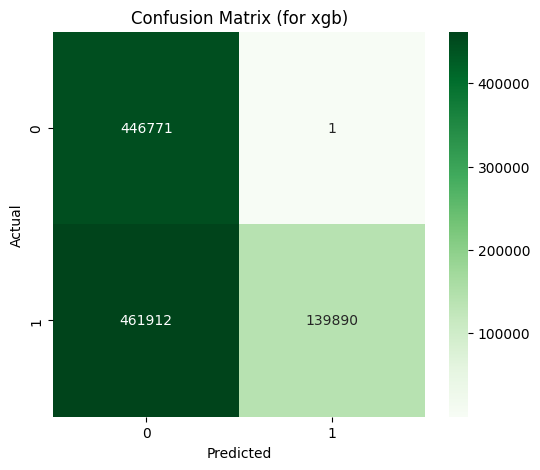

In [97]:
cm_rf = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (for xgb)")
plt.show()

In [115]:
# 3. Predict probabilities for the completely unseen test set (DoS attacks)
y_prob_xgb = xgb_final.predict_proba(X_test_xgb)[:, 1]

In [116]:
# 4. Calculate the OPTIMAL THRESHOLD to catch the zero-day attacks
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

In [117]:
# Calculate F1 score for each threshold safely
numerator = 2 * precisions[:-1] * recalls[:-1]
denominator = precisions[:-1] + recalls[:-1]
f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

In [118]:
# Find the threshold that yields the absolute best F1 Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal XGBoost Probability Threshold: {optimal_threshold:.6f}")

Optimal XGBoost Probability Threshold: 0.000755


In [119]:
# 5. Apply the tuned threshold for our final predictions
y_test_pred_xgb = (y_prob_xgb >= optimal_threshold).astype(int)

In [120]:
print("\n--- Final Sequential Model (LR -> RF -> XGB) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_xgb))


--- Final Sequential Model (LR -> RF -> XGB) Evaluation ---
Accuracy: 0.9956
F1 Score: 0.9962
ROC-AUC:  0.9937

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    446772
           1       1.00      1.00      1.00    601802

    accuracy                           1.00   1048574
   macro avg       1.00      1.00      1.00   1048574
weighted avg       1.00      1.00      1.00   1048574



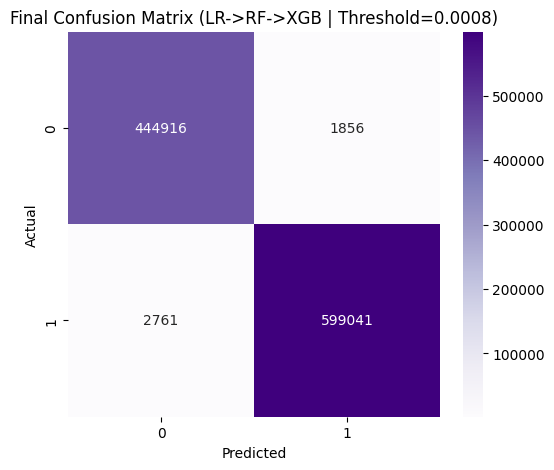

In [121]:
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Final Confusion Matrix (LR->RF->XGB | Threshold={optimal_threshold:.4f})")
plt.show()

In [122]:


print("--- Saving Predictions & Probabilities for ALL Models ---")

# 1. Gather the raw probabilities for all three stages
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf_final.predict_proba(X_test_rf)[:, 1]
xgb_probs = xgb_final.predict_proba(X_test_xgb)[:, 1]

# 2. Gather the actual 0/1 predictions for all three stages
# (Using the default 0.50 for LR and RF, and your custom threshold for XGBoost)
lr_preds = lr.predict(X_test)
rf_preds = rf_final.predict(X_test_rf)
xgb_preds_optimal = (xgb_probs >= optimal_threshold).astype(int)

# 3. Combine everything into a single, master DataFrame
all_results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'LR_Probability': lr_probs,
    'LR_Prediction': lr_preds,
    'RF_Probability': rf_probs,
    'RF_Prediction': rf_preds,
    'XGB_Probability': xgb_probs,
    'XGB_Prediction_Optimal': xgb_preds_optimal
})

# 4. Export the DataFrame to a CSV file
file_name = 'all_models_predictions_stage1_to_3.csv'
all_results_df.to_csv(file_name, index=False)

print(f"Successfully saved {len(all_results_df)} rows and {all_results_df.shape[1]} columns to '{file_name}'!")

--- Saving Predictions & Probabilities for ALL Models ---
Successfully saved 1048574 rows and 7 columns to 'all_models_predictions_stage1_to_3.csv'!


In [125]:
import joblib

print("--- Saving Trained Machine Learning Models ---")

# 1. Save the Stage 1: Logistic Regression model
joblib.dump(lr, 'stage1_logistic_regression.pkl')
print("Logistic Regression saved successfully!")

# 2. Save the Stage 2: Tuned Random Forest model
joblib.dump(rf_final, 'stage2_random_forest.pkl')
print("Random Forest saved successfully!")

# 3. Save the Stage 3: Tuned XGBoost Meta-Learner
joblib.dump(xgb_final, 'stage3_xgboost_metalearner.pkl')
print(" XGBoost saved successfully!")

# Optional: Save your optimal threshold value so you don't forget it!
with open('optimal_threshold.txt', 'w') as f:
    f.write(str(optimal_threshold))
print(f"Optimal Threshold ({optimal_threshold_val:.6f}) saved to text file!")

print("\nAll models are safely backed up to your working directory.")

--- Saving Trained Machine Learning Models ---
Logistic Regression saved successfully!
Random Forest saved successfully!
 XGBoost saved successfully!
Optimal Threshold (0.511431) saved to text file!

All models are safely backed up to your working directory.
